In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


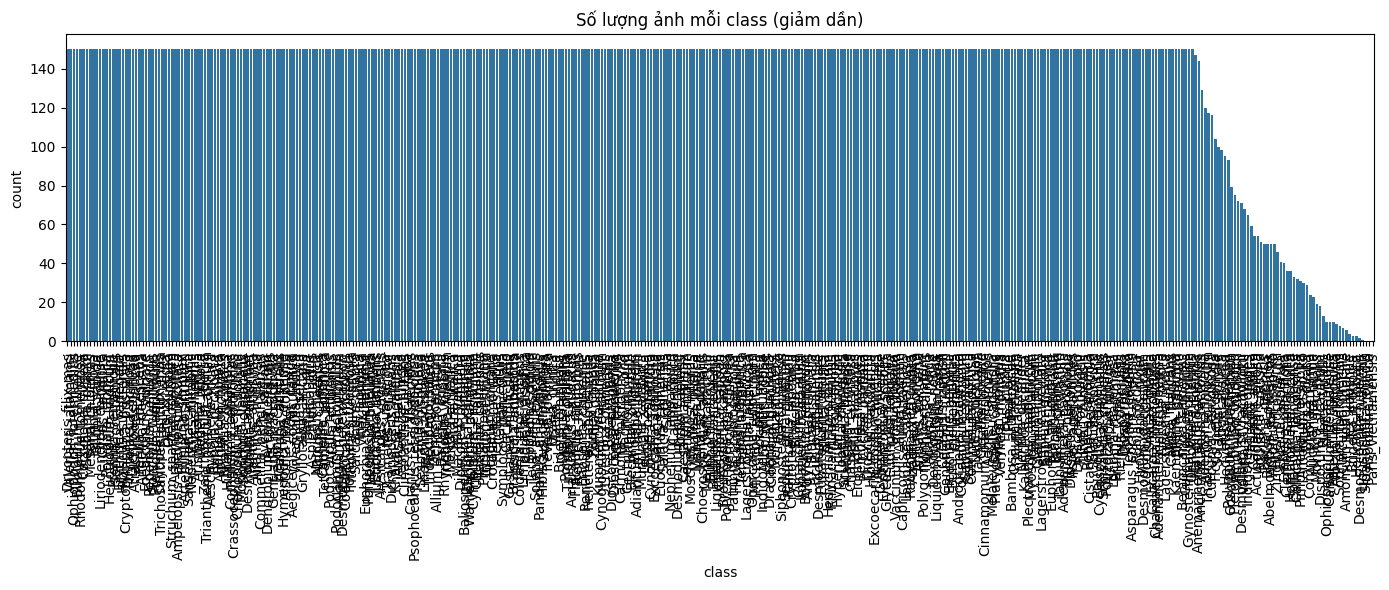

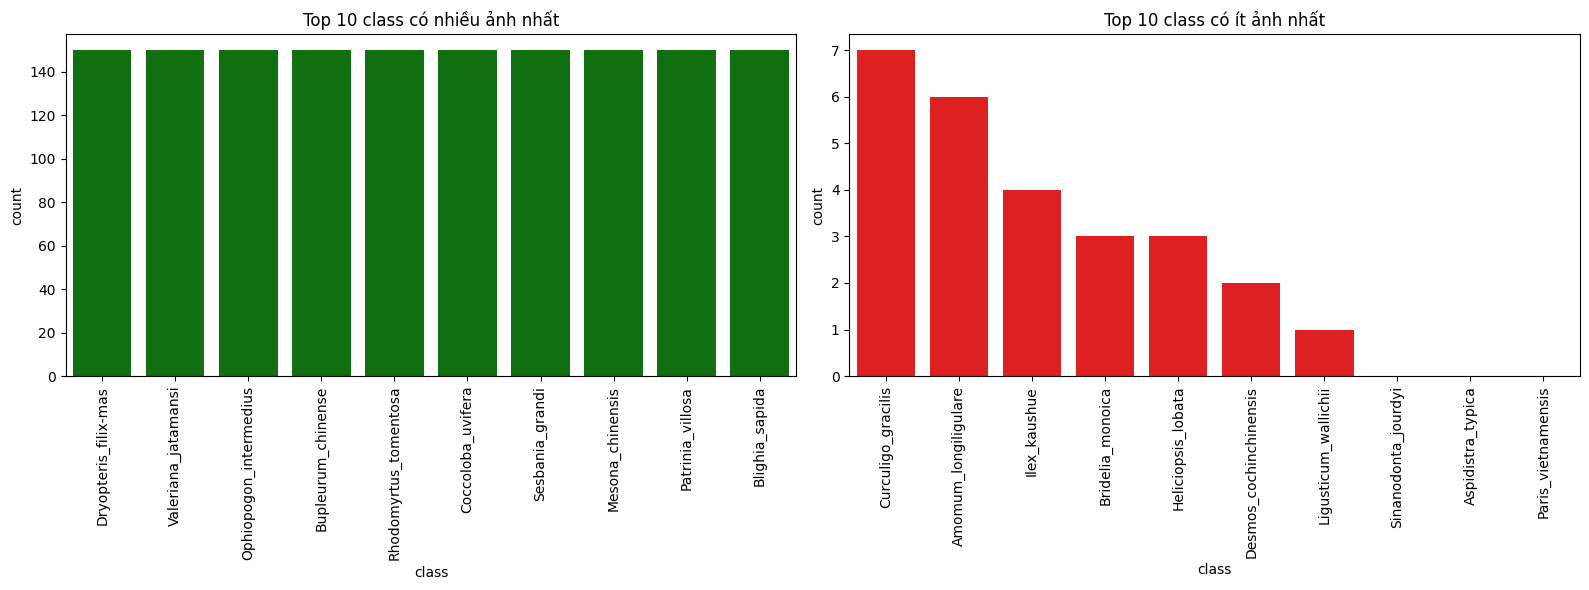

In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# Đường dẫn dataset gốc
root_path = "/content/drive/MyDrive/ML_Applications/project/dataset_duoclieu"

# Lấy danh sách folder class
class_folders = [os.path.join(root_path, d) for d in os.listdir(root_path)
                 if os.path.isdir(os.path.join(root_path, d))]

# Đếm ảnh từng folder
from collections import Counter

image_count = {}
extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")

for folder in class_folders:
    count = 0
    for f in os.listdir(folder):
        if f.lower().endswith(extensions):
            count += 1
    folder_name = os.path.basename(folder)
    image_count[folder_name] = count

# Chuyển sang DataFrame
df = pd.DataFrame(list(image_count.items()), columns=["class", "count"])
df_sorted = df.sort_values("count", ascending=False)

# ---------------------------------------
# Biểu đồ histplot số lượng ảnh (sort giảm dần)
# ---------------------------------------
plt.figure(figsize=(14, 6))

sns.barplot(data=df_sorted, x="class", y="count")
plt.xticks(rotation=90)
plt.title("Số lượng ảnh mỗi class (giảm dần)")
plt.tight_layout()
plt.show()

top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

plt.figure(figsize=(16, 6))

# Biểu đồ 1 – Top 10 class nhiều ảnh nhất
plt.subplot(1, 2, 1)
sns.barplot(data=top10, x="class", y="count", color='green')
plt.xticks(rotation=90)
plt.title("Top 10 class có nhiều ảnh nhất")

# Biểu đồ 2 – Top 10 class ít ảnh nhất
plt.subplot(1, 2, 2)
sns.barplot(data=bottom10, x="class", y="count", color='red')
plt.xticks(rotation=90)
plt.title("Top 10 class có ít ảnh nhất")

plt.tight_layout()
plt.show()




In [ ]:
# Đếm tổng số folder class
total_folders = len(class_folders)

# Đếm tổng số ảnh trong toàn dataset
total_images = df["count"].sum()

print("Tổng số folder class:", total_folders)
print("Tổng số ảnh trong toàn dataset:", total_images)


Tổng số folder class: 399
Tổng số ảnh trong toàn dataset: 54235


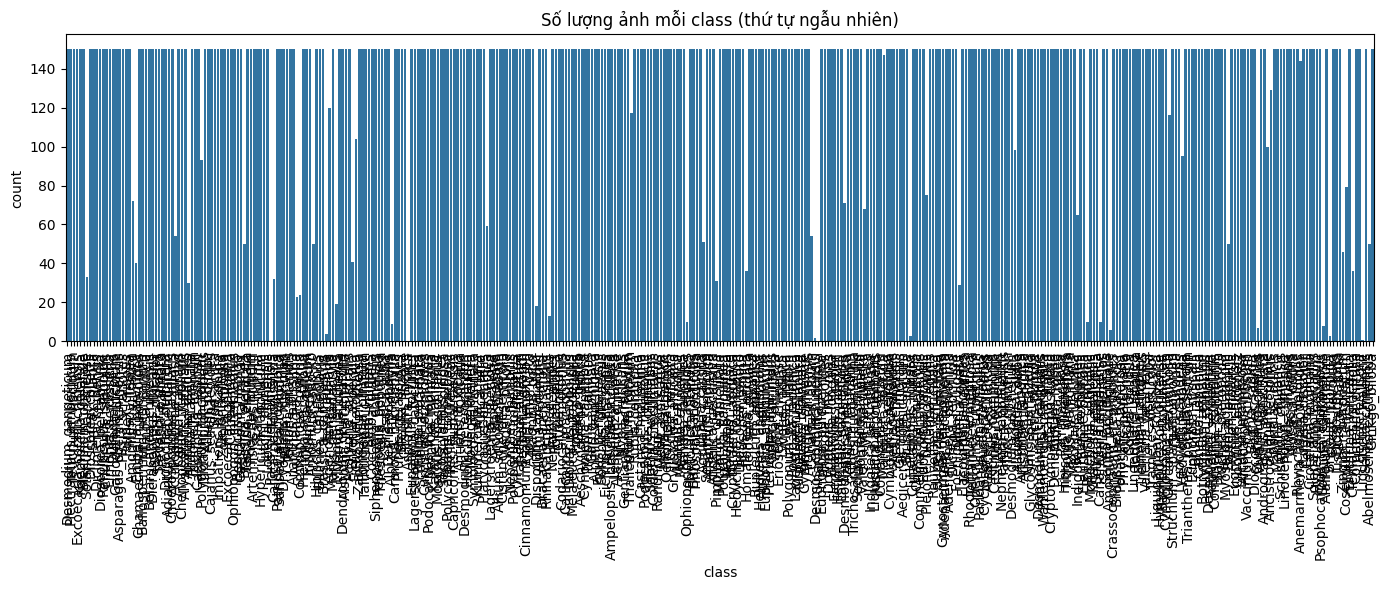

In [ ]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root_path = "/content/drive/MyDrive/ML_Applications/project/dataset_duoclieu"

# Lấy danh sách folder class
class_folders = [os.path.join(root_path, d) for d in os.listdir(root_path)
                 if os.path.isdir(os.path.join(root_path, d))]

# Đếm số ảnh từng folder
extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")
image_count = {}

for folder in class_folders:
    count = sum(1 for f in os.listdir(folder) if f.lower().endswith(extensions))
    folder_name = os.path.basename(folder)
    image_count[folder_name] = count

# Chuyển thành DataFrame
df = pd.DataFrame(list(image_count.items()), columns=["class", "count"])

# Xáo trộn ngẫu nhiên thứ tự các class
df_random = df.sample(frac=1, random_state=random.randint(1, 10000)).reset_index(drop=True)

# Vẽ biểu đồ với thứ tự ngẫu nhiên
plt.figure(figsize=(14, 6))
sns.barplot(data=df_random, x="class", y="count")
plt.xticks(rotation=90)
plt.title("Số lượng ảnh mỗi class (thứ tự ngẫu nhiên)")
plt.tight_layout()
plt.show()

In [ ]:
import zipfile
from collections import Counter
import pandas as pd

zip_path = "/content/drive/MyDrive/PBL6/Dataset_image/new_dataset-20251112T051321Z-1-001.zip"

# --- Mở file ZIP ---
with zipfile.ZipFile(zip_path, 'r') as z:
    # Lấy danh sách tất cả file trong zip
    all_files = z.namelist()

# --- Đếm số file theo class ---
counts = Counter()
for f in all_files:
    # Bỏ thư mục trống và chỉ lấy file
    if not f.endswith('/'):
        cls = f.split('/')[0]  # lớp là thư mục đầu tiên
        counts[cls] += 1

# --- Chuyển sang DataFrame và sắp xếp ---
df = pd.DataFrame(list(counts.items()), columns=["Class", "Num_Images"])
df_sorted = df.sort_values(by="Num_Images", ascending=False)

top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

print("Top 10 class có số ảnh nhiều nhất:")
print(top10)

print("\nBottom 10 class có số ảnh ít nhất:")
print(bottom10)


Top 10 class có số ảnh nhiều nhất:
         Class  Num_Images
0  new_dataset       20503

Bottom 10 class có số ảnh ít nhất:
         Class  Num_Images
0  new_dataset       20503


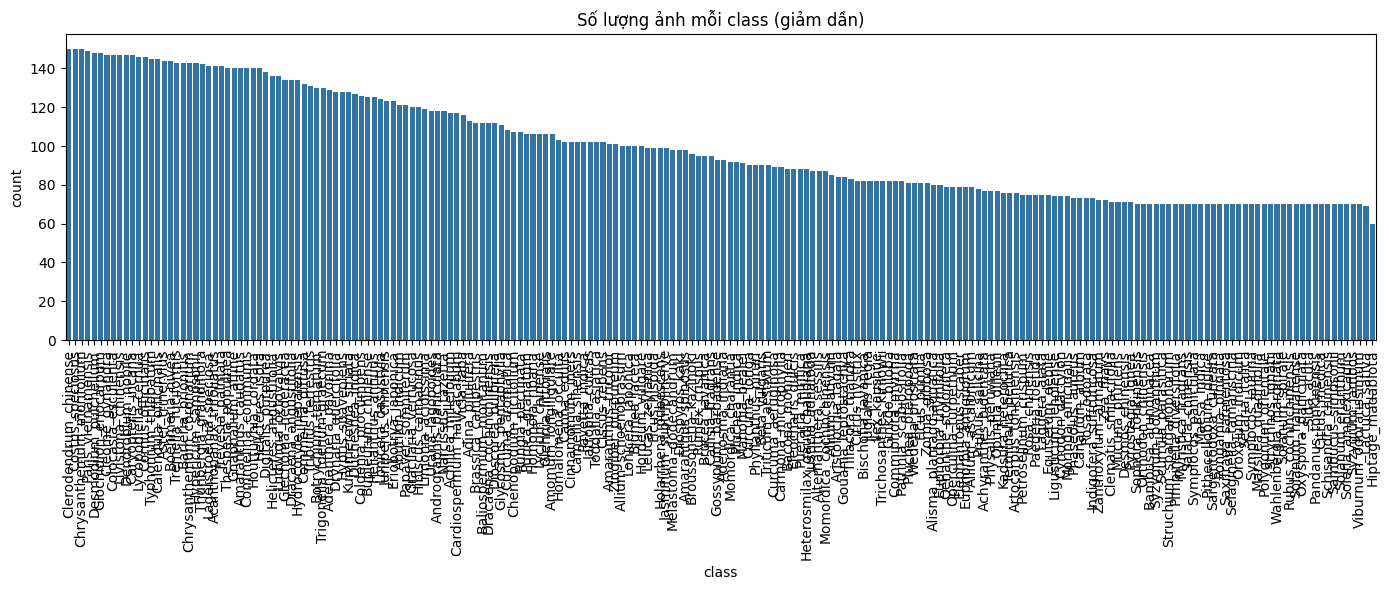

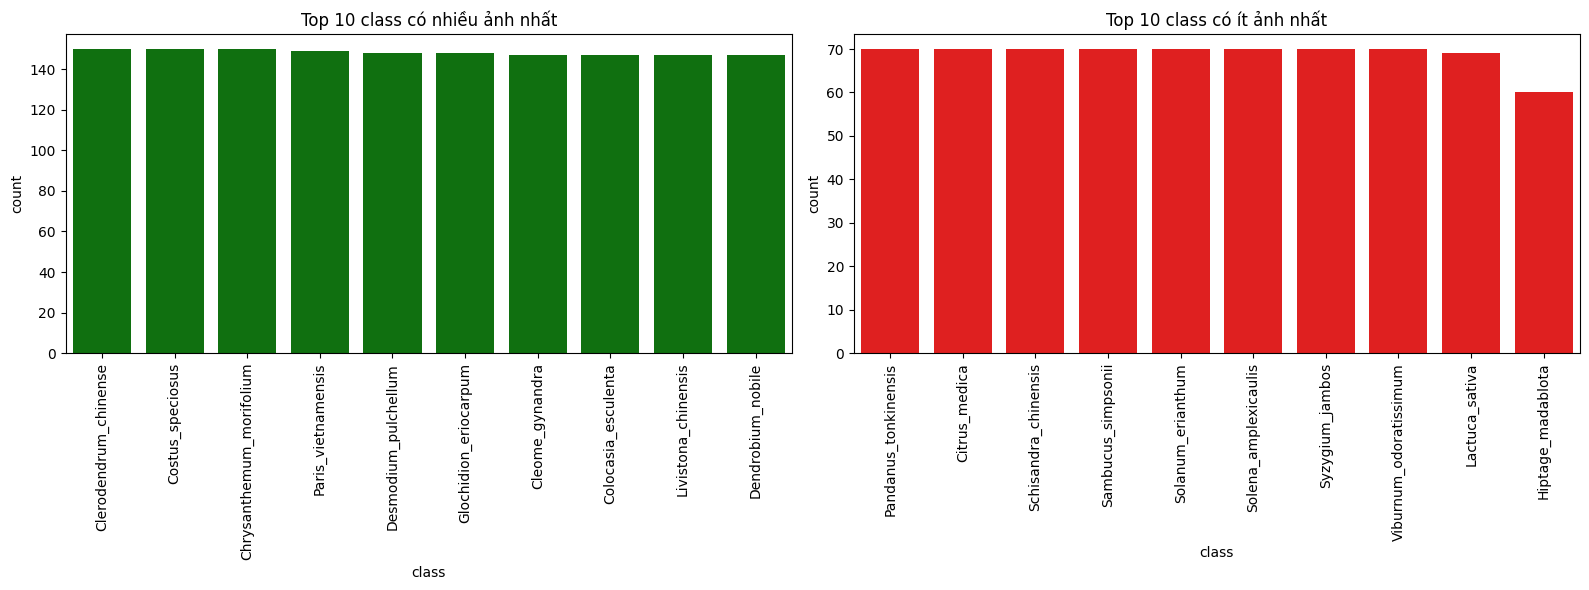

In [ ]:
import zipfile
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

zip_path = "/content/drive/MyDrive/PBL6/Dataset_image/new_dataset-20251112T051321Z-1-001.zip"

# --- Đếm số ảnh theo class trực tiếp từ ZIP ---
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    counts = Counter()
    for f in all_files:
        # Bỏ thư mục và chỉ lấy file ảnh
        if not f.endswith('/'):
            parts = f.split('/')
            if len(parts) > 2:  # new_dataset/class_name/file
                cls = parts[1]
                counts[cls] += 1

# --- Chuyển sang DataFrame và sắp xếp ---
df = pd.DataFrame(list(counts.items()), columns=["class", "count"])
df_sorted = df.sort_values(by="count", ascending=False)

# --- Vẽ biểu đồ số lượng ảnh mỗi class (giảm dần) ---
plt.figure(figsize=(14, 6))
sns.barplot(data=df_sorted, x="class", y="count")
plt.xticks(rotation=90)
plt.title("Số lượng ảnh mỗi class (giảm dần)")
plt.tight_layout()
plt.show()

# --- Lấy Top 10 và Bottom 10 ---
top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

# --- Biểu đồ Top 10 / Bottom 10 ---
plt.figure(figsize=(16, 6))

# Biểu đồ 1 – Top 10 class nhiều ảnh nhất
plt.subplot(1, 2, 1)
sns.barplot(data=top10, x="class", y="count", color='green')
plt.xticks(rotation=90)
plt.title("Top 10 class có nhiều ảnh nhất")

# Biểu đồ 2 – Top 10 class ít ảnh nhất
plt.subplot(1, 2, 2)
sns.barplot(data=bottom10, x="class", y="count", color='red')
plt.xticks(rotation=90)
plt.title("Top 10 class có ít ảnh nhất")

plt.tight_layout()
plt.show()
